# K-Means and DBSCAN Clustering

## Heart Disease Dataset

This notebook follows the assignment format:

- Part 1: EDA
- Part 2: Preprocessing
- Part 3: PCA
- Part 4: K-Means
- Part 5: DBSCAN
- Part 6: Evaluation
- Part 7: Comparison



# Part 1: EDA

EDA means Exploratory Data Analysis.

This part is split into multiple smaller blocks:

- 1.1 Import libraries and load dataset
- 1.2 Dataset overview
- 1.3 Missing values and duplicates
- 1.4 Summary statistics and target analysis
- 1.5 Histograms
- 1.6 Boxplots
- 1.7 Correlation heatmap
- 1.8 Outlier detection
- 1.9 EDA interpretation


## 1.1 Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
df = pd.read_csv("heart.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


## 1.2 Dataset Overview

In [2]:
print("Dataset Shape:")
print(df.shape)
print("\nFirst 5 Rows:")
display(df.head())
print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(1025, 14)

First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


## 1.3 Missing Values and Duplicates

In [3]:
print("Missing Values:")
print(df.isnull().sum())
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total Missing Values:
0

Duplicate Rows:
723


## 1.4 Summary Statistics and Target Analysis

Summary Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



Target Value Counts:
target
1    526
0    499
Name: count, dtype: int64

Target Percentage:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


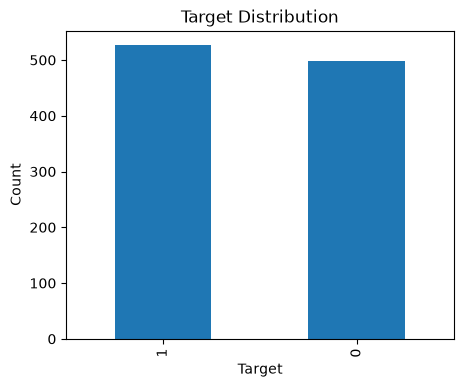

In [4]:
print("Summary Statistics:")
display(df.describe())
print("\nTarget Value Counts:")
print(df["target"].value_counts())
print("\nTarget Percentage:")
print(df["target"].value_counts(normalize=True) * 100)
plt.figure(figsize=(5,4))
df["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()
num_cols = df.columns.tolist()

## 1.5 Histograms

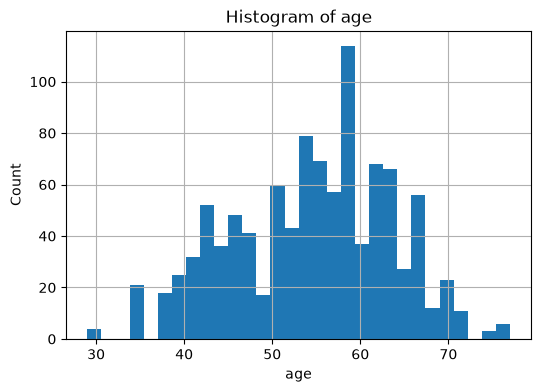

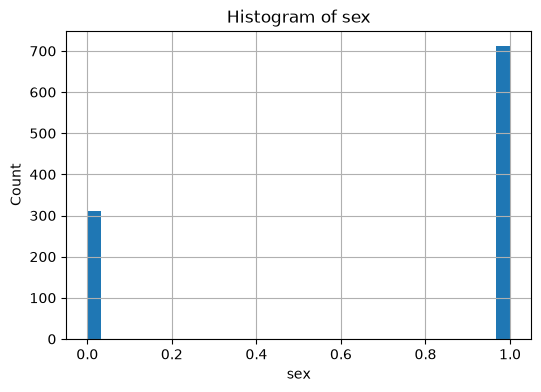

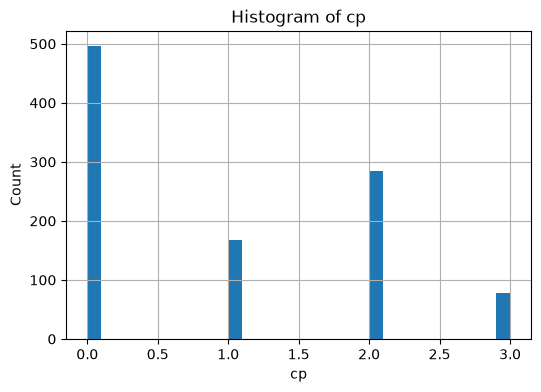

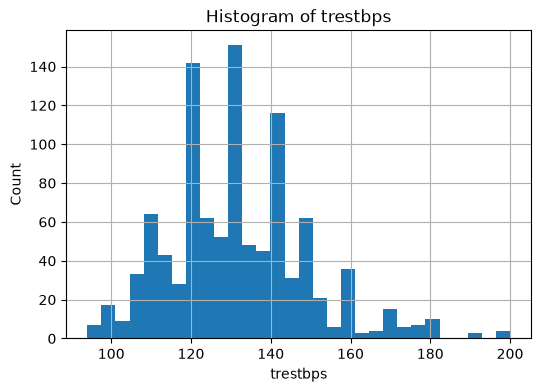

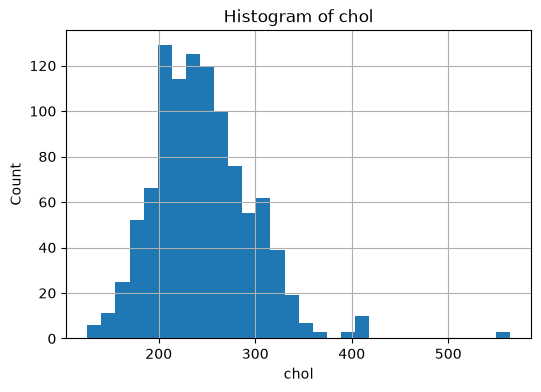

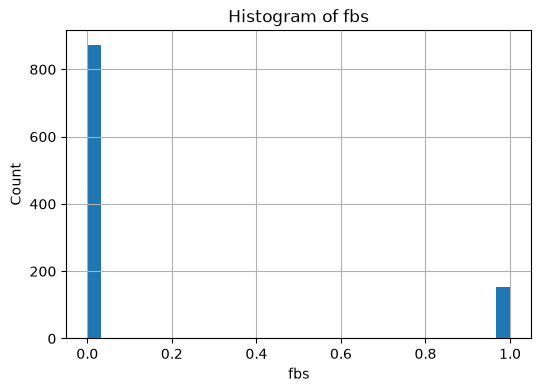

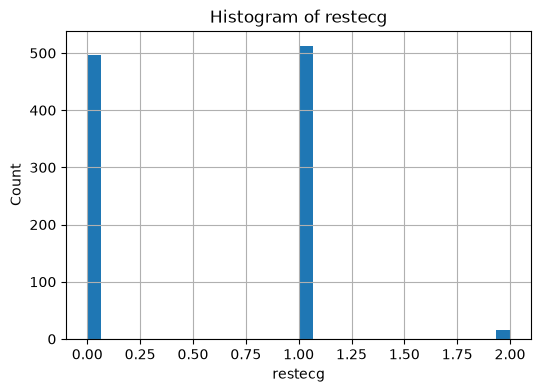

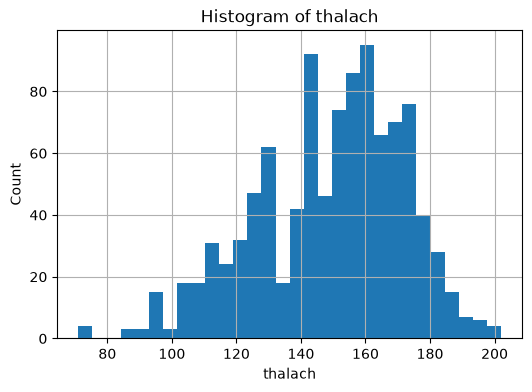

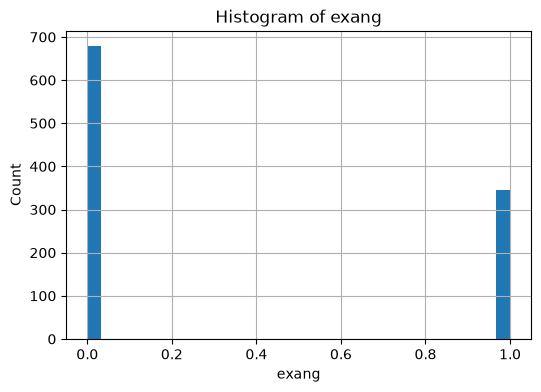

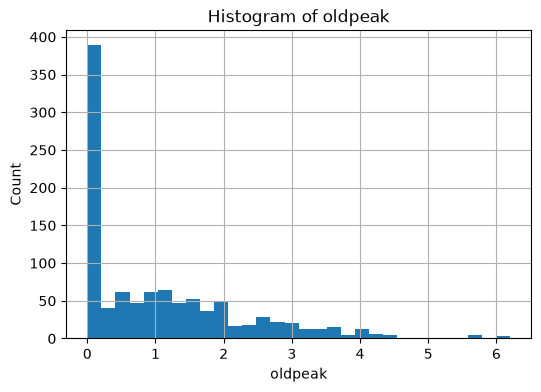

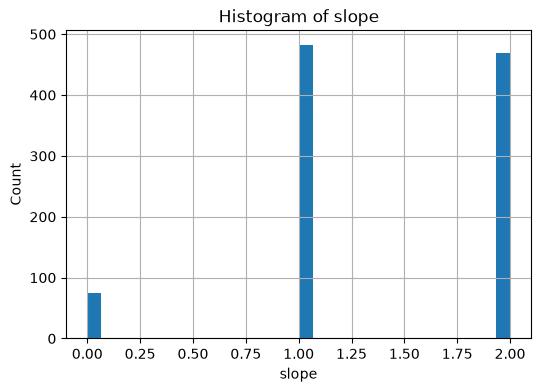

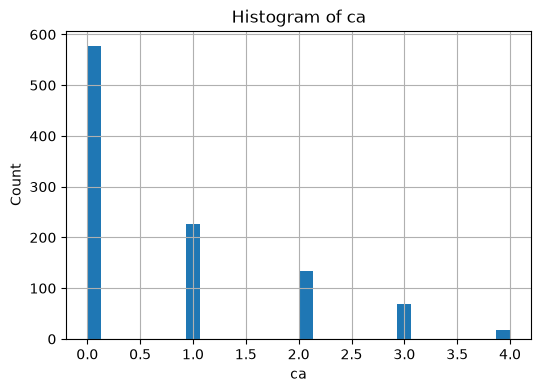

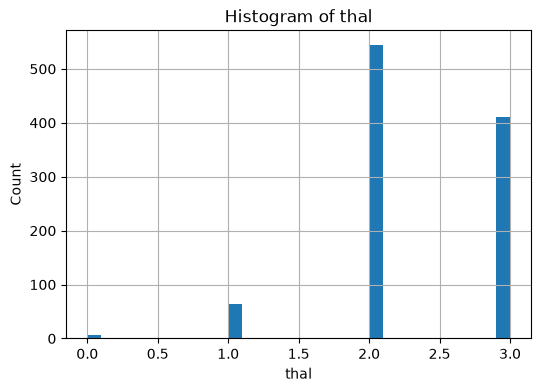

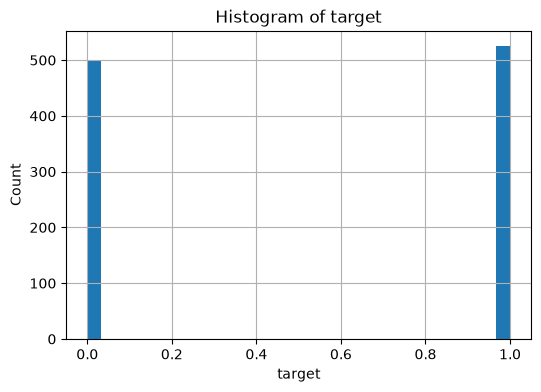

In [5]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=30)
    plt.title("Histogram of " + col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 1.6 Boxplots

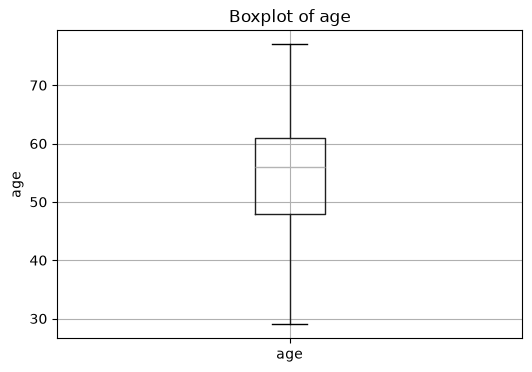

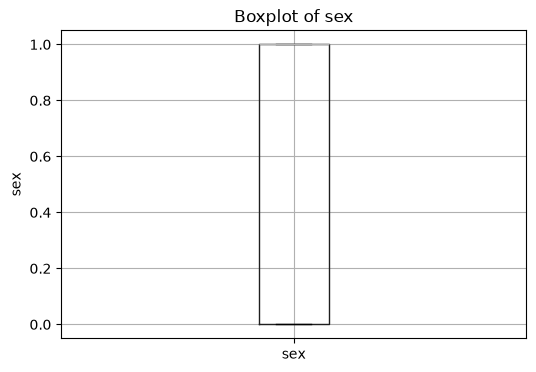

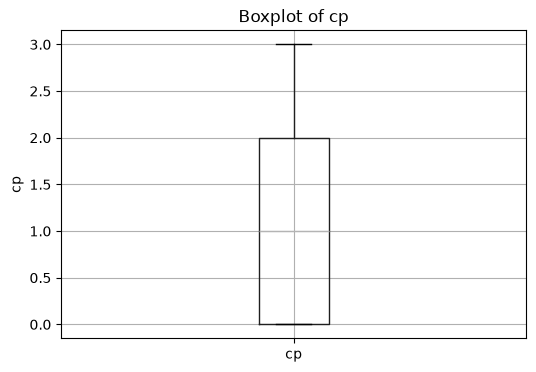

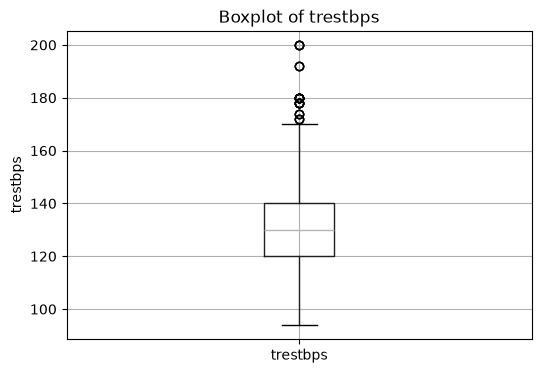

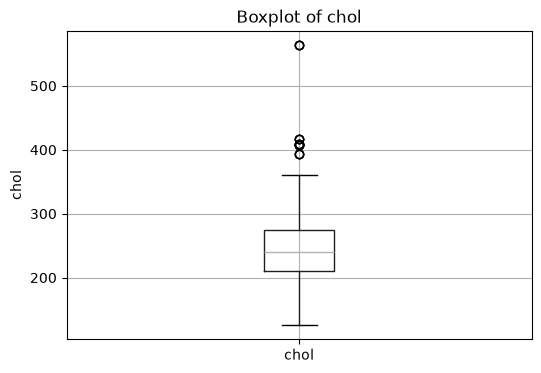

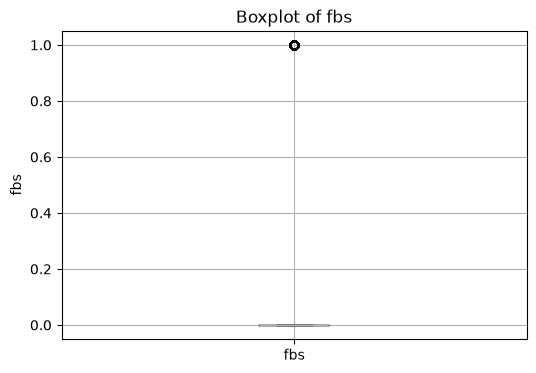

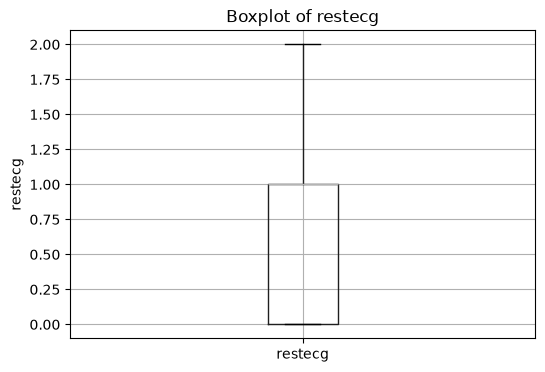

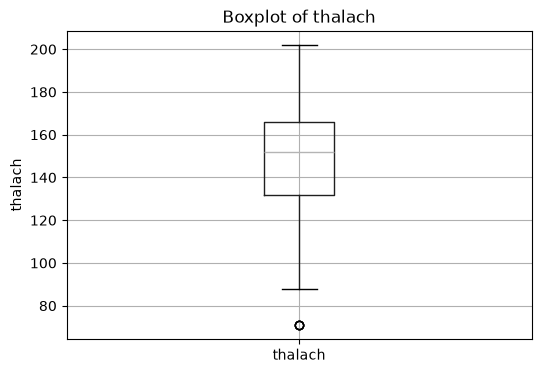

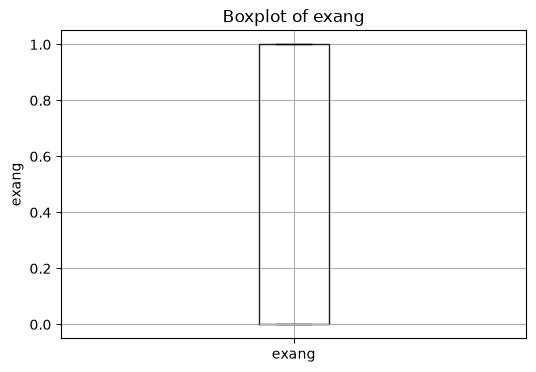

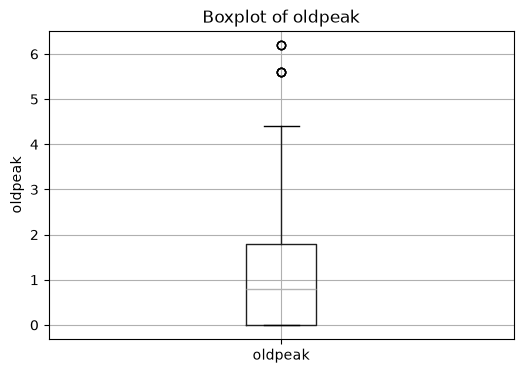

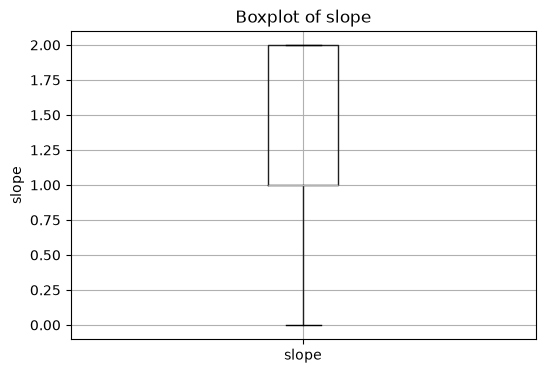

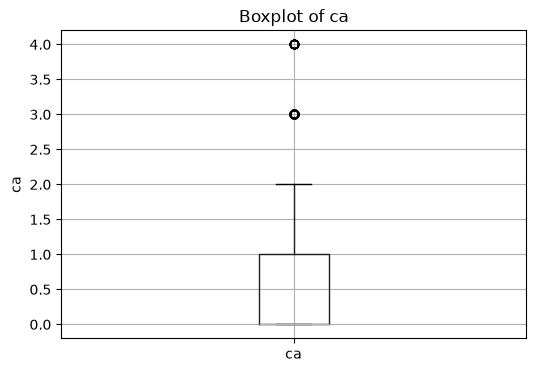

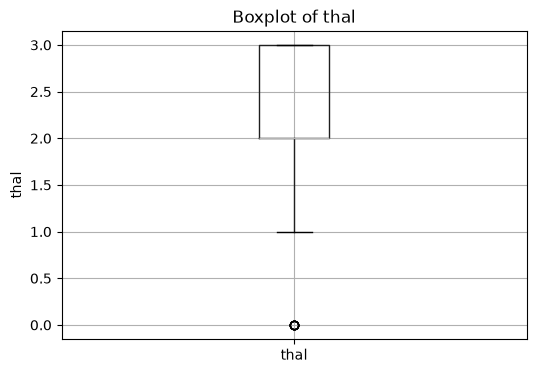

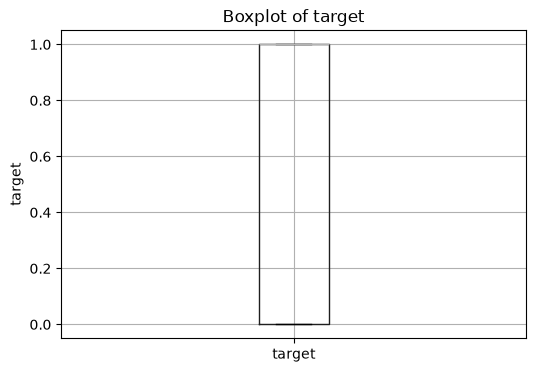

In [6]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col)
    plt.title("Boxplot of " + col)
    plt.ylabel(col)
    plt.show()

## 1.7 Correlation Heatmap

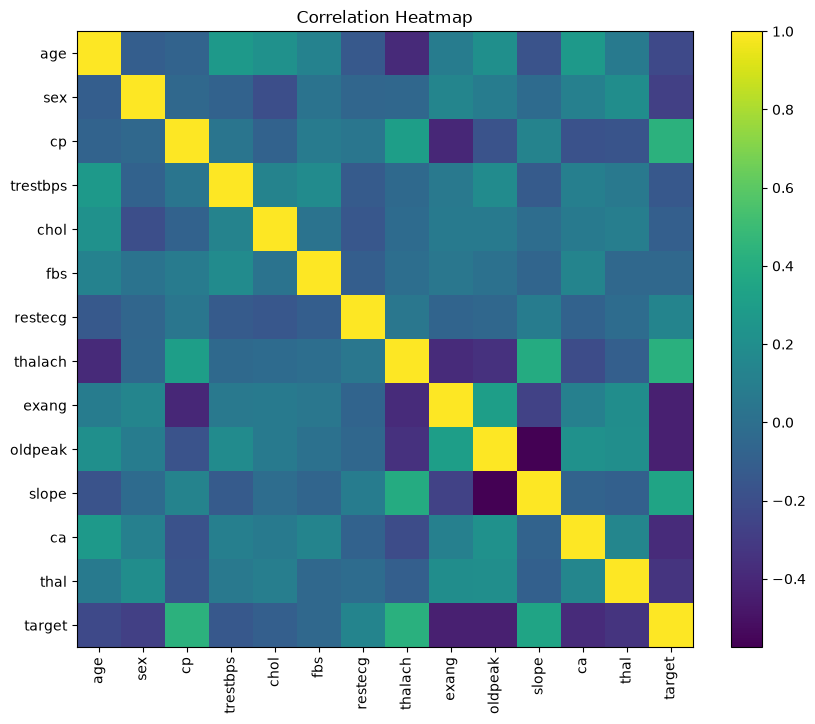

In [7]:
corr = df.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

## 1.8 Outlier Detection

In [8]:
print("Outlier Detection using IQR:")
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(col, ":", outliers)

Outlier Detection using IQR:
age : 0
sex : 0
cp : 0
trestbps : 30
chol : 16
fbs : 153
restecg : 0
thalach : 4
exang : 0
oldpeak : 7
slope : 0
ca : 87
thal : 7
target : 0


## 1.9 EDA Interpretation

In [9]:
print("EDA Interpretation:")
print("The dataset contains patient health measurements such as age, cholesterol, blood pressure, maximum heart rate, and chest pain type.")
print("The target column is useful for checking distribution, but it is removed before clustering.")
print("Histograms show feature distributions.")
print("Boxplots show possible outliers.")
print("The heatmap shows relationships between variables.")
print("Outlier detection identifies unusual values using IQR.")

EDA Interpretation:
The dataset contains patient health measurements such as age, cholesterol, blood pressure, maximum heart rate, and chest pain type.
The target column is useful for checking distribution, but it is removed before clustering.
Histograms show feature distributions.
Boxplots show possible outliers.
The heatmap shows relationships between variables.
Outlier detection identifies unusual values using IQR.


# Part 2: Preprocessing

This part is split into smaller blocks:

- 2.1 Copy data and remove duplicates
- 2.2 Handle missing values
- 2.3 Encode categorical variables
- 2.4 Remove target column
- 2.5 80/20 train-test split
- 2.6 Feature scaling using StandardScaler
- 2.7 Preprocessing summary


## 2.1 Copy Data and Remove Duplicates

In [10]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
print("Original Shape:")
print(df.shape)
print("\nShape After Removing Duplicates:")
print(df_clean.shape)

Original Shape:
(1025, 14)

Shape After Removing Duplicates:
(302, 14)


## 2.2 Handle Missing Values

In [11]:
for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
print("Missing Values After Treatment:")
print(df_clean.isnull().sum().sum())

Missing Values After Treatment:
0


## 2.3 Encode Categorical Variables

In [12]:
object_cols = df_clean.select_dtypes(include=["object"]).columns
if len(object_cols) > 0:
    df_clean = pd.get_dummies(df_clean, columns=object_cols, drop_first=True)
print("Categorical Encoding Completed")
print("Dataset Shape After Encoding:")
print(df_clean.shape)

Categorical Encoding Completed
Dataset Shape After Encoding:
(302, 14)


## 2.4 Remove Target Column Before Clustering

In [13]:
y_actual = df_clean["target"]
X = df_clean.drop("target", axis=1)
print("Target column removed before clustering")
print("Feature Shape:")
print(X.shape)
print("Target Shape:")
print(y_actual.shape)

Target column removed before clustering
Feature Shape:
(302, 13)
Target Shape:
(302,)


## 2.5 80/20 Train-Test Split

In [14]:
X_train, X_test, y_train_actual, y_test_actual = train_test_split(X, y_actual, test_size=0.20, random_state=42, stratify=y_actual)
print("Training Set Shape:")
print(X_train.shape)
print("\nTesting Set Shape:")
print(X_test.shape)
print("\nTraining Target Distribution:")
print(y_train_actual.value_counts(normalize=True) * 100)
print("\nTesting Target Distribution:")
print(y_test_actual.value_counts(normalize=True) * 100)

Training Set Shape:
(241, 13)

Testing Set Shape:
(61, 13)

Training Target Distribution:
target
1    54.356846
0    45.643154
Name: proportion, dtype: float64

Testing Target Distribution:
target
1    54.098361
0    45.901639
Name: proportion, dtype: float64


## 2.6 Feature Scaling Using StandardScaler

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
print("Scaling Completed")
print("Train Scaled Shape:")
print(X_train_scaled_df.shape)
print("Test Scaled Shape:")
print(X_test_scaled_df.shape)

Scaling Completed
Train Scaled Shape:
(241, 13)
Test Scaled Shape:
(61, 13)


## 2.7 Preprocessing Summary

In [16]:
print("Preprocessing Summary:")
print("Duplicates were removed.")
print("Missing values were handled using median for numerical columns and mode for categorical columns.")
print("Categorical variables were encoded if present.")
print("The target column was removed before clustering.")
print("An 80/20 train-test split was created.")
print("StandardScaler was applied after splitting to avoid data leakage.")
print("Training data will be used to fit clustering models.")

Preprocessing Summary:
Duplicates were removed.
Missing values were handled using median for numerical columns and mode for categorical columns.
Categorical variables were encoded if present.
The target column was removed before clustering.
An 80/20 train-test split was created.
StandardScaler was applied after splitting to avoid data leakage.
Training data will be used to fit clustering models.


# Part 3: PCA

This part is split into smaller blocks:

- 3.1 Train PCA on training data
- 3.2 Explained variance
- 3.3 PCA visualization
- 3.4 PCA interpretation


## 3.1 Train PCA on Training Data

In [17]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pca_train_df = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"])
pca_test_df = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"])
print("PCA Completed")
print("Training PCA Shape:")
print(pca_train_df.shape)
print("Testing PCA Shape:")
print(pca_test_df.shape)

PCA Completed
Training PCA Shape:
(241, 2)
Testing PCA Shape:
(61, 2)


## 3.2 Explained Variance

In [18]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("\nTotal Variance Retained:")
print(pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.20860316 0.12590689]

Total Variance Retained:
0.3345100546411172


## 3.3 PCA Visualization

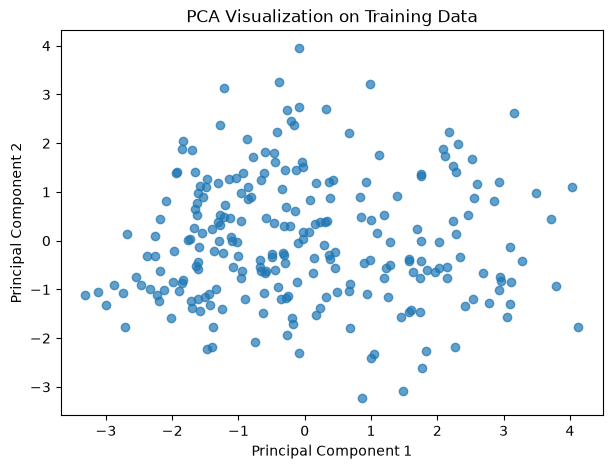

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(pca_train_df["PC1"], pca_train_df["PC2"], alpha=0.7)
plt.title("PCA Visualization on Training Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## 3.4 PCA Interpretation

In [20]:
print("PCA Interpretation:")
print("PCA reduces many features into two principal components.")
print("The two components are mainly used for visualization.")
print("PCA was fitted on training data and then applied to test data.")
print("The explained variance ratio tells how much information is retained.")

PCA Interpretation:
PCA reduces many features into two principal components.
The two components are mainly used for visualization.
PCA was fitted on training data and then applied to test data.
The explained variance ratio tells how much information is retained.


# Part 4: K-Means Clustering

This part is split into smaller blocks:

- 4.1 Elbow Method
- 4.2 Train K-Means on 80% training data
- 4.3 Predict train and test clusters
- 4.4 Visualize K-Means clusters
- 4.5 Interpret centroids
- 4.6 Cluster statistics


## 4.1 Elbow Method

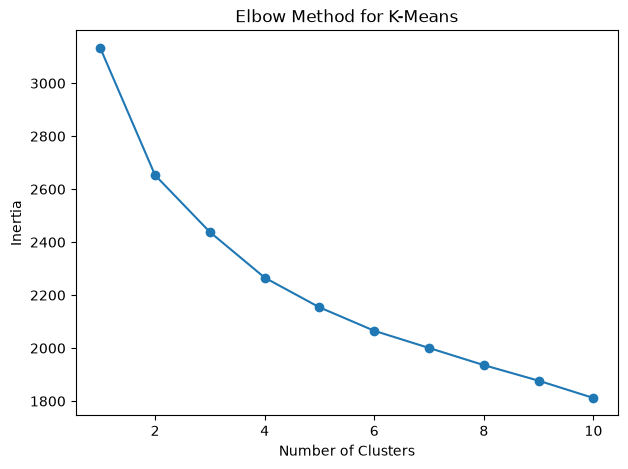

In [21]:
inertia_values = []
k_values = range(1,11)
for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_train_scaled)
    inertia_values.append(kmeans_temp.inertia_)
plt.figure(figsize=(7,5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

## 4.2 Train K-Means on Training Data

In [22]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
start_time = time.time()
kmeans_train_labels = kmeans.fit_predict(X_train_scaled)
kmeans_time = time.time() - start_time
print("K-Means Training Completed")
print("Training Time:")
print(kmeans_time)

K-Means Training Completed
Training Time:
0.022370576858520508


## 4.3 Predict Train and Test Clusters

In [23]:
kmeans_test_labels = kmeans.predict(X_test_scaled)
pca_train_df["KMeans_Cluster"] = kmeans_train_labels
pca_test_df["KMeans_Cluster"] = kmeans_test_labels
train_cluster_df = X_train.copy()
test_cluster_df = X_test.copy()
train_cluster_df["KMeans_Cluster"] = kmeans_train_labels
test_cluster_df["KMeans_Cluster"] = kmeans_test_labels
print("K-Means Train Cluster Counts:")
print(pd.Series(kmeans_train_labels).value_counts())
print("\nK-Means Test Cluster Counts:")
print(pd.Series(kmeans_test_labels).value_counts())

K-Means Train Cluster Counts:
1    158
0     83
Name: count, dtype: int64

K-Means Test Cluster Counts:
1    35
0    26
Name: count, dtype: int64


## 4.4 Visualize K-Means Clusters

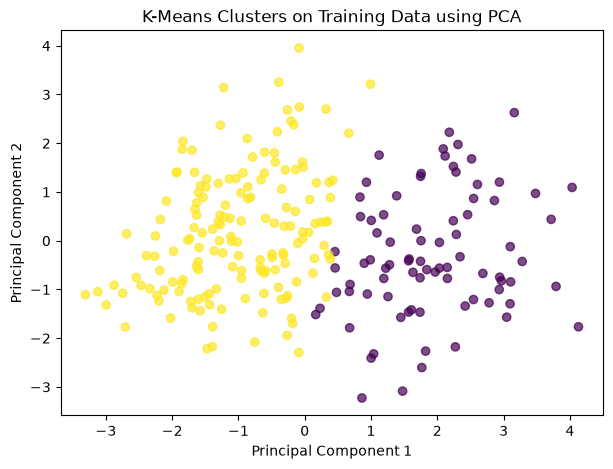

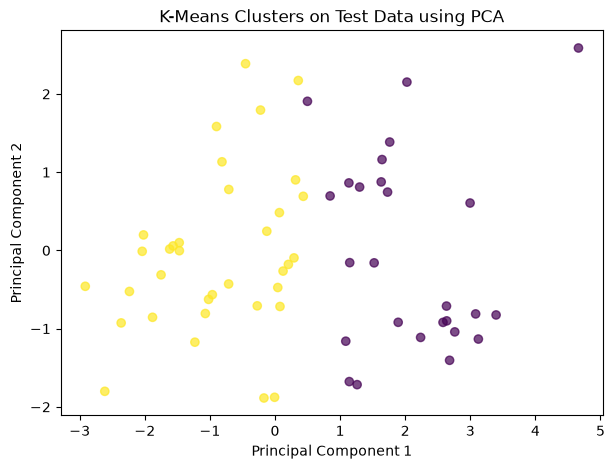

In [24]:
plt.figure(figsize=(7,5))
plt.scatter(pca_train_df["PC1"], pca_train_df["PC2"], c=pca_train_df["KMeans_Cluster"], alpha=0.7)
plt.title("K-Means Clusters on Training Data using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()
plt.figure(figsize=(7,5))
plt.scatter(pca_test_df["PC1"], pca_test_df["PC2"], c=pca_test_df["KMeans_Cluster"], alpha=0.7)
plt.title("K-Means Clusters on Test Data using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## 4.5 Interpret Centroids

In [25]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroid_table = pd.DataFrame(centroids_original, columns=X.columns)
print("K-Means Centroids in Original Feature Scale:")
display(centroid_table)
print("Centroids represent the average patient profile for each cluster.")

K-Means Centroids in Original Feature Scale:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,57.542169,0.759036,0.204819,134.951807,256.855422,0.144578,0.506024,132.301205,0.698795,1.867470,1.048193,1.361446,2.638554
1,52.436709,0.632911,1.392405,129.405063,242.784810,0.132911,0.550633,160.556962,0.088608,0.537342,1.620253,0.443038,2.177215


Centroids represent the average patient profile for each cluster.


## 4.6 K-Means Cluster Statistics

In [26]:
print("Training Cluster Statistics:")
display(train_cluster_df.groupby("KMeans_Cluster").mean())
print("\nTest Cluster Statistics:")
display(test_cluster_df.groupby("KMeans_Cluster").mean())
print("\nK-Means Interpretation:")
print("K-Means groups patients into 2 clusters based on similarity in health measurements.")
print("The model was trained on 80% of the data and used to assign clusters to the 20% test data.")

Training Cluster Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
KMeans_Cluster,,,,,,,,,,,,,
0,57.542169,0.759036,0.204819,134.951807,256.855422,0.144578,0.506024,132.301205,0.698795,1.867470,1.048193,1.361446,2.638554
1,52.436709,0.632911,1.392405,129.405063,242.784810,0.132911,0.550633,160.556962,0.088608,0.537342,1.620253,0.443038,2.177215



Test Cluster Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
KMeans_Cluster,,,,,,,,,,,,,
0,61.192308,0.769231,0.346154,140.269231,239.730769,0.230769,0.423077,126.576923,0.807692,1.780769,0.923077,1.076923,2.384615
1,50.942857,0.657143,1.285714,127.142857,243.742857,0.171429,0.542857,158.000000,0.171429,0.822857,1.571429,0.171429,2.114286



K-Means Interpretation:
K-Means groups patients into 2 clusters based on similarity in health measurements.
The model was trained on 80% of the data and used to assign clusters to the 20% test data.


# Part 5: DBSCAN Clustering

This part is split into smaller blocks:

- 5.1 K-distance plot
- 5.2 Train DBSCAN on training data
- 5.3 Visualize DBSCAN clusters
- 5.4 Identify noise points
- 5.5 DBSCAN cluster statistics
- 5.6 DBSCAN interpretation


## 5.1 K-Distance Plot

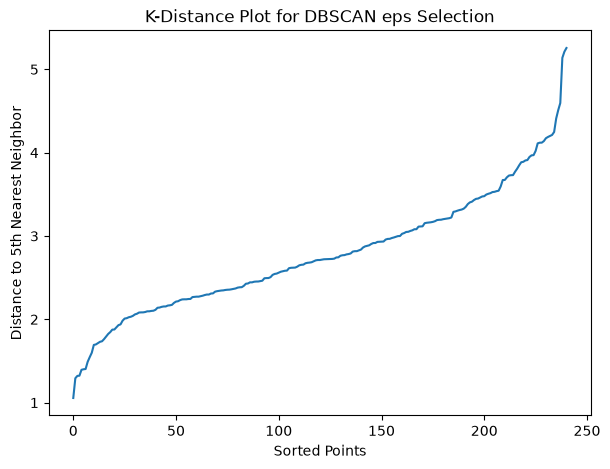

In [27]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_train_scaled)
distances, indices = neighbors_fit.kneighbors(X_train_scaled)
distances = np.sort(distances[:, min_samples - 1])
plt.figure(figsize=(7,5))
plt.plot(distances)
plt.title("K-Distance Plot for DBSCAN eps Selection")
plt.xlabel("Sorted Points")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.show()

## 5.2 Train DBSCAN on Training Data

In [28]:
eps_value = 2.5
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
start_time = time.time()
dbscan_train_labels = dbscan.fit_predict(X_train_scaled)
dbscan_time = time.time() - start_time
pca_train_df["DBSCAN_Cluster"] = dbscan_train_labels
train_cluster_df["DBSCAN_Cluster"] = dbscan_train_labels
print("DBSCAN Training Completed")
print("Training Time:")
print(dbscan_time)

DBSCAN Training Completed
Training Time:
0.0039691925048828125


## 5.3 Visualize DBSCAN Clusters

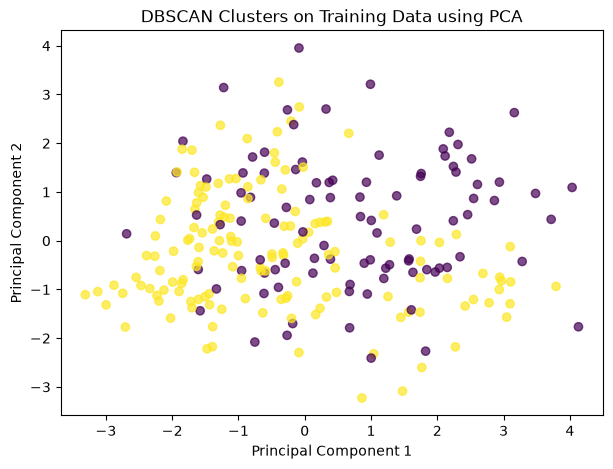

In [29]:
plt.figure(figsize=(7,5))
plt.scatter(pca_train_df["PC1"], pca_train_df["PC2"], c=pca_train_df["DBSCAN_Cluster"], alpha=0.7)
plt.title("DBSCAN Clusters on Training Data using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## 5.4 Identify Noise Points

In [30]:
print("DBSCAN Cluster Counts:")
print(pd.Series(dbscan_train_labels).value_counts())
noise_points = (dbscan_train_labels == -1).sum()
print("\nNoise Points:")
print(noise_points)
print("\nNoise Percentage:")
print((noise_points / len(dbscan_train_labels)) * 100)

DBSCAN Cluster Counts:
 0    146
-1     95
Name: count, dtype: int64

Noise Points:
95

Noise Percentage:
39.41908713692946


## 5.5 DBSCAN Cluster Statistics

In [31]:
print("DBSCAN Cluster Statistics:")
display(train_cluster_df.groupby("DBSCAN_Cluster").mean())

DBSCAN Cluster Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,KMeans_Cluster
DBSCAN_Cluster,,,,,,,,,,,,,,
-1,56.863158,0.684211,0.989474,136.042105,253.115789,0.347368,0.515789,143.936842,0.389474,1.292632,1.168421,1.157895,2.284211,0.484211
0,52.458904,0.671233,0.979452,128.239726,244.061644,0.000000,0.547945,155.308219,0.239726,0.802055,1.589041,0.500000,2.369863,0.767123


## 5.6 DBSCAN Interpretation

In [32]:
print("DBSCAN Interpretation:")
print("DBSCAN forms clusters based on dense regions in the training data.")
print("Points labeled -1 are noise or possible outliers.")
print("DBSCAN does not support normal predict on test data like K-Means.")
print("So DBSCAN was fitted and evaluated on the training data.")

DBSCAN Interpretation:
DBSCAN forms clusters based on dense regions in the training data.
Points labeled -1 are noise or possible outliers.
DBSCAN does not support normal predict on test data like K-Means.
So DBSCAN was fitted and evaluated on the training data.


# Part 6: Evaluation

This part is split into smaller blocks:

- 6.1 Define evaluation function
- 6.2 Evaluate K-Means
- 6.3 Evaluate DBSCAN
- 6.4 Create evaluation table
- 6.5 Explain metrics


## 6.1 Define Evaluation Function

In [33]:
def evaluate_clustering(name, data, labels, training_time):
    unique_labels = set(labels)
    if -1 in unique_labels:
        mask = labels != -1
        labels_eval = labels[mask]
        data_eval = data[mask]
    else:
        labels_eval = labels
        data_eval = data
    if len(set(labels_eval)) < 2:
        return [name, "Not valid", "Not valid", "Not valid", training_time, len(unique_labels), (labels == -1).sum()]
    silhouette = silhouette_score(data_eval, labels_eval)
    davies = davies_bouldin_score(data_eval, labels_eval)
    calinski = calinski_harabasz_score(data_eval, labels_eval)
    return [name, silhouette, davies, calinski, training_time, len(unique_labels), (labels == -1).sum()]
print("Evaluation function created")

Evaluation function created


## 6.2 Evaluate K-Means

In [34]:
kmeans_train_eval = evaluate_clustering("K-Means Train", X_train_scaled, kmeans_train_labels, kmeans_time)
kmeans_test_eval = evaluate_clustering("K-Means Test", X_test_scaled, kmeans_test_labels, 0)
print("K-Means Train Evaluation:")
print(kmeans_train_eval)
print("\nK-Means Test Evaluation:")
print(kmeans_test_eval)

K-Means Train Evaluation:
['K-Means Train', 0.16827226824363017, 2.1962459746133147, 43.25214762618396, 0.022370576858520508, 2, np.int64(0)]

K-Means Test Evaluation:
['K-Means Test', 0.16189939240113688, 2.086507288840047, 12.71561522444973, 0, 2, np.int64(0)]


## 6.3 Evaluate DBSCAN

In [35]:
dbscan_eval = evaluate_clustering("DBSCAN Train", X_train_scaled, dbscan_train_labels, dbscan_time)
print("DBSCAN Evaluation:")
print(dbscan_eval)

DBSCAN Evaluation:
['DBSCAN Train', 'Not valid', 'Not valid', 'Not valid', 0.0039691925048828125, 2, np.int64(95)]


## 6.4 Create Evaluation Table

In [36]:
evaluation_table = pd.DataFrame([kmeans_train_eval, kmeans_test_eval, dbscan_eval], columns=["Algorithm", "Silhouette Score", "Davies-Bouldin Index", "Calinski-Harabasz Score", "Training Time", "Number of Labels", "Noise Points"])
print("Clustering Evaluation Table:")
display(evaluation_table)

Clustering Evaluation Table:


,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Training Time,Number of Labels,Noise Points
0,K-Means Train,0.168272,2.196246,43.252148,0.022371,2,0
1,K-Means Test,0.161899,2.086507,12.715615,0.000000,2,0
2,DBSCAN Train,Not valid,Not valid,Not valid,0.003969,2,95


## 6.5 Explain Evaluation Metrics

In [37]:
print("Evaluation Metric Meaning:")
print("Higher Silhouette Score is better.")
print("Lower Davies-Bouldin Index is better.")
print("Higher Calinski-Harabasz Score is better.")
print("Noise points are important for DBSCAN because they show unusual patient records.")

Evaluation Metric Meaning:
Higher Silhouette Score is better.
Lower Davies-Bouldin Index is better.
Higher Calinski-Harabasz Score is better.
Noise points are important for DBSCAN because they show unusual patient records.


# Part 7: Comparison

This part is split into smaller blocks:

- 7.1 Display comparison table
- 7.2 K-Means advantages and limitations
- 7.3 DBSCAN advantages and limitations
- 7.4 Final recommendation


## 7.1 Display Comparison Table

In [38]:
print("K-Means vs DBSCAN Comparison:")
display(evaluation_table)

K-Means vs DBSCAN Comparison:


,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Training Time,Number of Labels,Noise Points
0,K-Means Train,0.168272,2.196246,43.252148,0.022371,2,0
1,K-Means Test,0.161899,2.086507,12.715615,0.000000,2,0
2,DBSCAN Train,Not valid,Not valid,Not valid,0.003969,2,95


## 7.2 K-Means Advantages and Limitations

In [39]:
print("K-Means Advantages:")
print("K-Means is simple, fast, and easy to interpret.")
print("K-Means can assign clusters to new test data using predict.")
print("\nK-Means Limitations:")
print("K-Means requires choosing the number of clusters before training.")
print("K-Means is sensitive to outliers.")

K-Means Advantages:
K-Means is simple, fast, and easy to interpret.
K-Means can assign clusters to new test data using predict.

K-Means Limitations:
K-Means requires choosing the number of clusters before training.
K-Means is sensitive to outliers.


## 7.3 DBSCAN Advantages and Limitations

In [40]:
print("DBSCAN Advantages:")
print("DBSCAN can detect noise points.")
print("DBSCAN does not require choosing the number of clusters before training.")
print("DBSCAN can find irregular cluster shapes.")
print("\nDBSCAN Limitations:")
print("DBSCAN depends strongly on eps and min_samples.")
print("DBSCAN does not have a simple predict method for test data.")
print("DBSCAN may not work well when density varies across clusters.")

DBSCAN Advantages:
DBSCAN can detect noise points.
DBSCAN does not require choosing the number of clusters before training.
DBSCAN can find irregular cluster shapes.

DBSCAN Limitations:
DBSCAN depends strongly on eps and min_samples.
DBSCAN does not have a simple predict method for test data.
DBSCAN may not work well when density varies across clusters.


## 7.4 Final Recommendation

In [41]:
print("Final Recommendation:")
print("K-Means is better when we want a fixed number of patient groups and need to assign new test data to clusters.")
print("DBSCAN is better when we want to detect unusual patients or possible outliers.")
print("For this assignment, K-Means is easier to interpret, while DBSCAN is useful for noise detection.")

Final Recommendation:
K-Means is better when we want a fixed number of patient groups and need to assign new test data to clusters.
DBSCAN is better when we want to detect unusual patients or possible outliers.
For this assignment, K-Means is easier to interpret, while DBSCAN is useful for noise detection.


# Bonus: Healthcare and Business Insights + Agglomerative Clustering

This part is split into smaller blocks:

- Bonus 1: Train Agglomerative Clustering
- Bonus 2: Visualize Agglomerative clusters
- Bonus 3: Evaluate Agglomerative Clustering
- Bonus 4: Final comparison
- Bonus 5: Healthcare and business insights


## Bonus 1: Train Agglomerative Clustering

In [42]:
agg = AgglomerativeClustering(n_clusters=2)
start_time = time.time()
agg_train_labels = agg.fit_predict(X_train_scaled)
agg_time = time.time() - start_time
pca_train_df["Agglomerative_Cluster"] = agg_train_labels
train_cluster_df["Agglomerative_Cluster"] = agg_train_labels
print("Agglomerative Clustering Completed")
print("Training Time:")
print(agg_time)

Agglomerative Clustering Completed
Training Time:
0.13148736953735352


## Bonus 2: Visualize Agglomerative Clusters

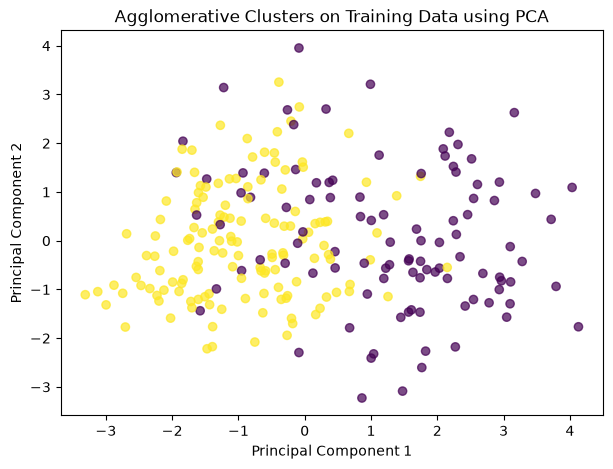

In [43]:
plt.figure(figsize=(7,5))
plt.scatter(pca_train_df["PC1"], pca_train_df["PC2"], c=pca_train_df["Agglomerative_Cluster"], alpha=0.7)
plt.title("Agglomerative Clusters on Training Data using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Bonus 3: Evaluate Agglomerative Clustering

In [44]:
agg_eval = evaluate_clustering("Agglomerative Train", X_train_scaled, agg_train_labels, agg_time)
print("Agglomerative Evaluation:")
print(agg_eval)

Agglomerative Evaluation:
['Agglomerative Train', 0.13000046830583153, 2.7852375818319777, 29.444878086781976, 0.13148736953735352, 2, np.int64(0)]


## Bonus 4: Final Comparison

In [45]:
final_comparison = pd.DataFrame([kmeans_train_eval, kmeans_test_eval, dbscan_eval, agg_eval], columns=["Algorithm", "Silhouette Score", "Davies-Bouldin Index", "Calinski-Harabasz Score", "Training Time", "Number of Labels", "Noise Points"])
print("Final Algorithm Comparison:")
display(final_comparison)
print("\nAgglomerative Cluster Statistics:")
display(train_cluster_df.groupby("Agglomerative_Cluster").mean())

Final Algorithm Comparison:


,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Training Time,Number of Labels,Noise Points
0,K-Means Train,0.168272,2.196246,43.252148,0.022371,2,0
1,K-Means Test,0.161899,2.086507,12.715615,0.000000,2,0
2,DBSCAN Train,Not valid,Not valid,Not valid,0.003969,2,95
3,Agglomerative Train,0.13,2.785238,29.444878,0.131487,2,0



Agglomerative Cluster Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,KMeans_Cluster,DBSCAN_Cluster
Agglomerative_Cluster,,,,,,,,,,,,,,,
0,56.627451,0.705882,0.558824,135.480392,256.058824,0.323529,0.509804,136.411765,0.519608,1.623529,1.117647,1.068627,2.441176,0.303922,-0.686275
1,52.410072,0.654676,1.294964,128.258993,241.446043,0.000000,0.553957,161.402878,0.136691,0.534532,1.647482,0.532374,2.258993,0.913669,-0.179856


## Bonus 5: Healthcare and Business Insights

In [46]:
print("Healthcare and Business Insights:")
print("1. Patients can be grouped into different risk profiles based on clinical measurements.")
print("2. Age, cholesterol, blood pressure, and maximum heart rate help describe patient groups.")
print("3. Cluster statistics can help hospitals identify higher-risk patient segments.")
print("4. DBSCAN noise points may represent unusual patients who need closer review.")
print("5. K-Means is useful when hospitals want a fixed number of patient groups.")
print("6. DBSCAN is useful when hospitals want to detect outliers or abnormal cases.")
print("7. PCA visualization helps doctors and analysts understand patient grouping visually.")
print("8. Clustering can support preventive care, patient segmentation, and resource planning.")
print("\nAgglomerative Clustering Comparison:")
print("Agglomerative Clustering also creates patient groups but uses a hierarchy-based approach.")
print("It is easier to understand using hierarchy, but it can be slower on larger datasets.")

Healthcare and Business Insights:
1. Patients can be grouped into different risk profiles based on clinical measurements.
2. Age, cholesterol, blood pressure, and maximum heart rate help describe patient groups.
3. Cluster statistics can help hospitals identify higher-risk patient segments.
4. DBSCAN noise points may represent unusual patients who need closer review.
5. K-Means is useful when hospitals want a fixed number of patient groups.
6. DBSCAN is useful when hospitals want to detect outliers or abnormal cases.
7. PCA visualization helps doctors and analysts understand patient grouping visually.
8. Clustering can support preventive care, patient segmentation, and resource planning.

Agglomerative Clustering Comparison:
Agglomerative Clustering also creates patient groups but uses a hierarchy-based approach.
It is easier to understand using hierarchy, but it can be slower on larger datasets.


# Final Conclusion

This notebook completed clustering analysis on the Heart Disease dataset.

The workflow included:

- EDA segmented into multiple smaller blocks
- Preprocessing segmented into multiple smaller blocks
- 80/20 train-test split
- StandardScaler
- PCA
- K-Means
- DBSCAN
- Evaluation metrics
- Algorithm comparison
- Business insights
- Agglomerative Clustering bonus

K-Means is simple and can assign clusters to test data.  
DBSCAN is useful for identifying noise and unusual patient records.  
Agglomerative Clustering provides a hierarchy-based comparison.
